In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [4]:
train_df = pd.read_csv("../data/processed/train_processed.csv")
test_df = pd.read_csv("../data/processed/test_processed.csv")

print(train_df.shape)
print(test_df.shape)

train_df.head()

(6513, 20)
(1050, 20)


,State,District,Year,Crop,Season,Area,Rainfall_mm,Avg_Temperature_C,Max_Temperature_C,Min_Temperature_C,Relative_Humidity_Percent,NDVI,EVI,LST_C,Soil_Moisture,Evapotranspiration_mm,Solar_Radiation_MJ,Soil_Organic_Carbon,Soil_pH,Yield
0,0.0,-1.727678,-1.617086,-1.454394,-0.817363,-0.260367,0.93964,0.757413,0.668452,0.635654,0.293265,-0.060953,0.014582,0.340817,1.369565,-0.242325,-0.50873,-0.888035,-0.233172,3.55
1,0.0,-1.727678,-1.617086,-1.454394,0.876396,-0.303074,0.93964,0.757413,0.668452,0.635654,0.293265,-0.060953,0.014582,0.340817,1.369565,-0.242325,-0.50873,-0.888035,-0.233172,2.44
2,0.0,-1.727678,-1.617086,-1.315636,-0.817363,-0.304883,0.93964,0.757413,0.668452,0.635654,0.293265,-0.060953,0.014582,0.340817,1.369565,-0.242325,-0.50873,-0.888035,-0.233172,0.32
3,0.0,-1.727678,-1.617086,-1.176878,-0.817363,0.337387,0.93964,0.757413,0.668452,0.635654,0.293265,-0.060953,0.014582,0.340817,1.369565,-0.242325,-0.50873,-0.888035,-0.233172,1.43
4,0.0,-1.727678,-1.617086,-1.176878,0.876396,-0.286932,0.93964,0.757413,0.668452,0.635654,0.293265,-0.060953,0.014582,0.340817,1.369565,-0.242325,-0.50873,-0.888035,-0.233172,2.96


In [5]:
X_train = train_df.drop(columns=["Yield"])
y_train = train_df["Yield"]

X_test = test_df.drop(columns=["Yield"])
y_test = test_df["Yield"]

print(X_train.shape)
print(X_test.shape)

(6513, 19)
(1050, 19)


In [6]:
print(X_train.columns.tolist())

['State', 'District', 'Year', 'Crop', 'Season', 'Area', 'Rainfall_mm', 'Avg_Temperature_C', 'Max_Temperature_C', 'Min_Temperature_C', 'Relative_Humidity_Percent', 'NDVI', 'EVI', 'LST_C', 'Soil_Moisture', 'Evapotranspiration_mm', 'Solar_Radiation_MJ', 'Soil_Organic_Carbon', 'Soil_pH']


In [26]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("Random Forest Training Completed!")

Random Forest Training Completed!


In [27]:
y_pred = rf.predict(X_test)

print(y_pred[:10])

[2.935   2.053   0.28455 1.49485 2.4059  3.11345 4.4282  0.69875 1.1022
 0.7896 ]


In [28]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.3507338571428572
RMSE: 0.7002604152963045
R²  : 0.9547264387250055


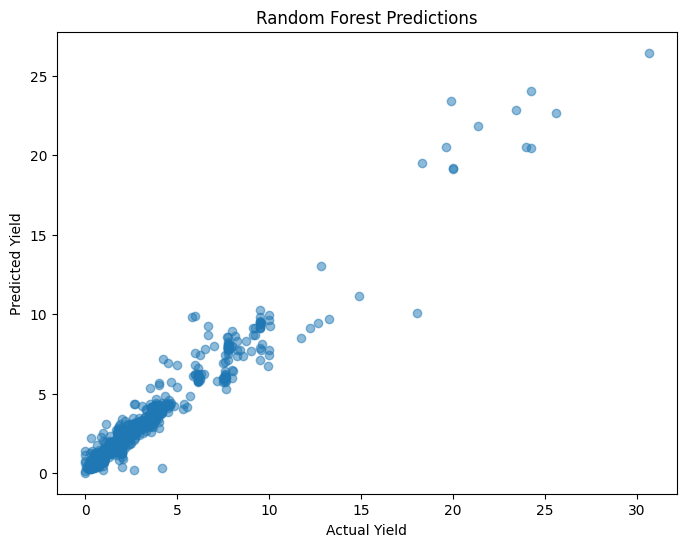

In [29]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")

plt.title("Random Forest Predictions")

plt.show()

In [30]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
3,Crop,0.815157
5,Area,0.036526
4,Season,0.025650
6,Rainfall_mm,0.016810
2,Year,0.015046
1,District,0.013535
9,Min_Temperature_C,0.010790
17,Soil_Organic_Carbon,0.009307
16,Solar_Radiation_MJ,0.009207
18,Soil_pH,0.008575


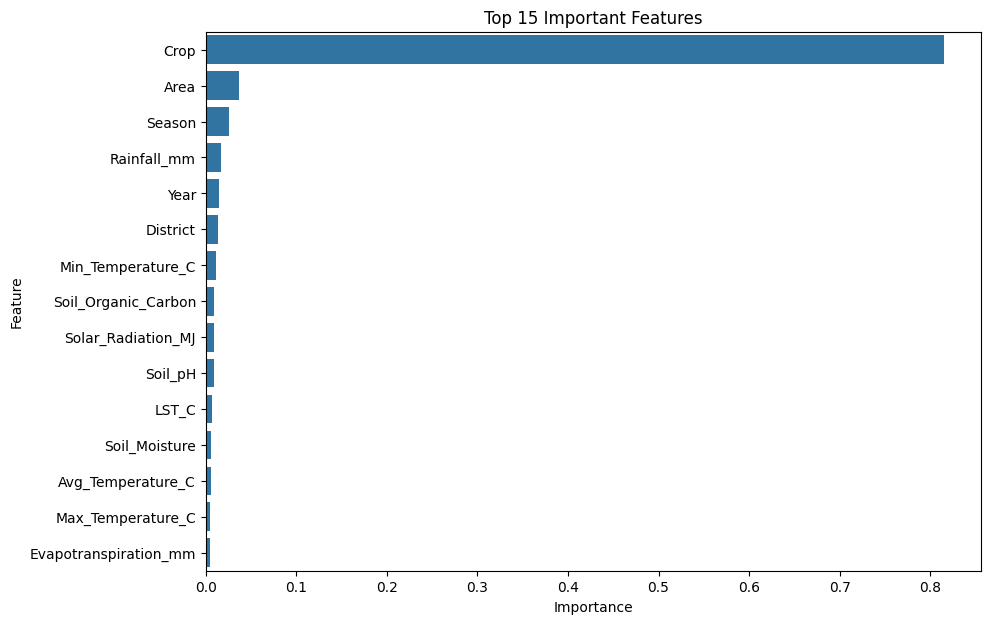

In [31]:
plt.figure(figsize=(10,7))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.show()

In [32]:
joblib.dump(rf, "../models/random_forest_model.pkl")

print("Random Forest Model Saved!")

Random Forest Model Saved!


In [33]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 989.2 kB/s eta 0:01:43
   ---------------------------------------- 0.5/101.7 MB 989.2 kB/s eta 0:01:43
   ---------------------------------------- 0.8/101.7 MB 799.2 kB/s eta 0:02:07
   ---------------------------------------- 1.0/101.7 MB 915.5 kB/s eta 0:01:50
    --------------------------------------- 1.6/101.7 MB 1.1 MB/s eta 0:01:31
    --------------------------------------- 1.8/101.7 MB 1.2 MB/s eta 0:01:26
    --------------------------------------- 2.1/101.7 MB 1.2 MB/s eta 0:01:22
    --------------------------------------- 2.4/101.7 MB 1.3 MB/s eta 0:01:20
   - -------------------------------------- 2.6/101.7 MB 1.3 MB/s eta 0:01:18
   - -


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
from xgboost import XGBRegressor

In [35]:
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

print("XGBoost Training Completed!")

XGBoost Training Completed!


In [36]:
y_pred_xgb = xgb.predict(X_test)

In [37]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("R²  :", r2_xgb)

MAE : 0.4266468312694026
RMSE: 0.8741590106937008
R²  : 0.9294484789856235


In [38]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "MAE": [mae, mae_xgb],
    "RMSE": [rmse, rmse_xgb],
    "R2 Score": [r2, r2_xgb]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Random Forest,0.350734,0.700260,0.954726
1,XGBoost,0.426647,0.874159,0.929448


In [39]:
joblib.dump(xgb, "../models/xgboost_model.pkl")

['../models/xgboost_model.pkl']